In [4]:
import pandas as pd
import pyomo.environ as pyo
from pyomo.environ import SolverFactory
from pyomo.environ import *

## Exercicio 1 - GOAL PROGRAMMING

In [5]:

produto = ['p1','p2']

lucro ={
    produto[0]:5,
    produto[1]:4,
}


In [62]:
model = pyo.ConcreteModel()

model.produtos = pyo.Set(initialize=produto)
model.lucro = pyo.Param(model.produtos,initialize=lucro)

model.p1 = pyo.Var(domain=pyo.NonNegativeIntegers)
model.p2 = pyo.Var(domain=pyo.NonNegativeIntegers)

# POR MULTI OBJETIVO
model.obj1_menos = pyo.Var(domain=pyo.NonNegativeIntegers)
model.obj1_mais = pyo.Var(domain=pyo.NonNegativeIntegers)
model.obj2_menos = pyo.Var(domain=pyo.NonNegativeIntegers)
model.obj2_mais = pyo.Var(domain=pyo.NonNegativeIntegers)

# obj
def rojb(model):
    return model.obj1_menos+model.obj2_menos
model.fobj=pyo.Objective(rule=rojb, sense=pyo.minimize)

#Constrict
#Recursos
def rhoras(model):
    return 2*model.p1+model.p2<= 40
model.fhoras = pyo.Constraint(rule=rhoras)

def rmp(model):
    return model.p1+2*model.p2<=30
model.fmp=pyo.Constraint(rule=rmp)

#Obj-Constraint
#d1
def rlucro(model):
    return 5*model.p1+4*model.p2+model.obj1_menos-model.obj1_mais ==100
model.flucro = pyo.Constraint(rule=rlucro)

#d2
def rprod(model):
    return model.p1+model.p2 + model.obj2_menos - model.obj2_mais ==18
model.fprod = pyo.Constraint(rule=rprod)


In [63]:
model.pprint()

1 Set Declarations
    produtos : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    2 : {'p1', 'p2'}

1 Param Declarations
    lucro : Size=2, Index=produtos, Domain=Any, Default=None, Mutable=False
        Key : Value
         p1 :     5
         p2 :     4

6 Var Declarations
    obj1_mais : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeIntegers
    obj1_menos : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeIntegers
    obj2_mais : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeIntegers
    obj2_menos : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None

In [64]:
opt = SolverFactory('cplex', executable='C:\\Program Files\\IBM\\ILOG\\CPLEX_Studio_Community222\\cplex\\bin\\x64_win64\\cplex.exe')
res = opt.solve(model,tee=True)



Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer Community Edition 22.2.0.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2026.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\Pichau\AppData\Local\Temp\tmpx99bzmw7.cplex.log' open.
CPLEX> Problem 'C:\Users\Pichau\AppData\Local\Temp\tmp0ipwkpx6.pyomo.lp' read.
Read time = 0.00 sec. (0.00 ticks)
CPLEX> Problem name         : C:\Users\Pichau\AppData\Local\Temp\tmp0ipwkpx6.pyomo.lp
Objective sense      : Minimize
Variables            :       6  [General Integer: 6]
Objective nonzeros   :       2
Linear constraints   :       4  [Less: 2,  Equal: 2]
  Nonzeros           :      12
  RHS nonzeros       :       4

Variables            : Min LB: 0.000000         Max UB: all infinite   
Objective nonz

In [66]:
model.display()

Model unknown

  Variables:
    p1 : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  20.0 :  None : False : False : NonNegativeIntegers
    p2 : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  -0.0 :  None : False : False : NonNegativeIntegers
    obj1_menos : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  -0.0 :  None : False : False : NonNegativeIntegers
    obj1_mais : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  -0.0 :  None : False : False : NonNegativeIntegers
    obj2_menos : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  -0.0 :  None : False : False : NonNegativeIntegers
    obj2_mais : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :   2.

#-----------------------------------------

## Exercício 1 - NSGA-II

In [86]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination
from pymoo.optimize import minimize

class MyProblem(ElementwiseProblem):

    def __init__(self):
        super().__init__(n_var=2,
                         n_obj=2,
                         n_ieq_constr=2,
                         xl=0,
                         xu=30)

    def _evaluate(self, x, out, *args, **kwargs):

        f1 = 5*x[0] + 4*x[1]
        f2 = x[0] + x[1]

        # As restrições precisam ser <= 0 
        g1 = 2*x[0] + x[1] - 40
        g2 = x[0] + 2*x[1] - 30

        out["F"] = [-f1,-f2]
        out["G"] = [g1, g2]


problem = MyProblem()

algorithm = NSGA2(
    pop_size=40,
    n_offsprings=10,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 40)

res = minimize(problem,
               algorithm,
               termination,
               seed=1,
               save_history=True,
               verbose=True)

X = res.X
F = res.F

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       40 |      2 |  0.000000E+00 |  3.402347E+01 |             - |             -
     2 |       50 |      2 |  0.000000E+00 |  2.031500E+01 |  0.000000E+00 |             f
     3 |       60 |      2 |  0.000000E+00 |  1.019854E+01 |  0.8962004542 |         ideal
     4 |       70 |      1 |  0.000000E+00 |  3.4825479724 |  3.6832992673 |         ideal
     5 |       80 |      1 |  0.000000E+00 |  1.1077490017 |  5.1433604308 |         ideal
     6 |       90 |      1 |  0.000000E+00 |  0.2141831051 |  0.000000E+00 |             f
     7 |      100 |      2 |  0.000000E+00 |  0.000000E+00 |  1.0000000000 |         ideal
     8 |      110 |      1 |  0.000000E+00 |  0.000000E+00 |  1.1130895251 |         ideal
     9 |      120 |      2 |  0.000000E+00 |  0.000000E+00 |  1.0000000000 |         ideal
    10 |      130 |      2 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f

In [89]:
print('--------X')
print(X)
print('--------F')
print(F)
print("---------res.G")
print(res.G)

--------X
[[16.34493807  6.71514718]
 [16.95234343  6.07026836]]
--------F
[[-108.58527906  -23.06008525]
 [-109.04279063  -23.0226118 ]]
---------res.G
[[-0.59497668 -0.22476757]
 [-0.02504477 -0.90711984]]


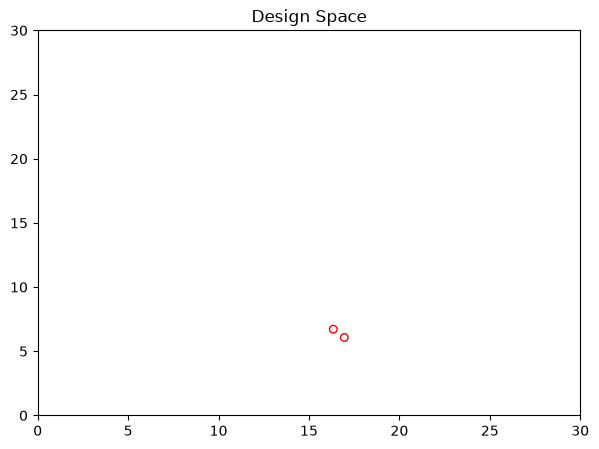

In [88]:
import matplotlib.pyplot as plt
xl, xu = problem.bounds()
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=30, facecolors='none', edgecolors='r')
plt.xlim(xl[0], xu[0])
plt.ylim(xl[1], xu[1])
plt.title("Design Space")
plt.show()